## Dataset up 

In [105]:
include("main_utils.jl")
include("data_setup.jl")
include("comix_uk_time_series.jl")

get_mean_over_time (generic function with 1 method)

In [ ]:
df, df_part = read_raw_sc_data_with_sday("comix_uk");
df, df_part = read_adult_chunks(df, df_part);

In [55]:
df_dds = create_df_dds_chunk(df, df_part)
CSV.write("../dt_intermediate/df_dds.csv", df_dds)

Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of removing ids: 0
Number of re

"../dt_intermediate/df_dds.csv"

## BNB for the later period

In [2]:
include("main_utils.jl")
include("data_setup.jl")
include("comix_uk_time_series.jl")

get_mean_over_time (generic function with 1 method)

In [3]:
df_dds = @pipe CSV.read("../dt_intermediate/df_dds.csv", DataFrame) |>
    @rename(_, :date = :key) |>
    @transform(_, :key = string.(:date));
df_dds_late = @subset(df_dds, :date .>= Date(2021, 7, 1));
dds_nhm_late = @subset(df_dds_late, :strat .== "non-home") |> merge_dd

DegreeDist([0, 1, 2, 3, 4, 5, 6, 7, 8, 9  …  1100, 1306, 1513, 1750, 1799, 2000, 2002, 2011, 2750, 4020], [71726, 6215, 4854, 2890, 1546, 992, 645, 407, 297, 194  …  1, 1, 1, 2, 1, 1, 1, 1, 1, 1], true)

In [ ]:
chn = fit_model_with_forward_mode(model_BNB2(dds_nhm_late), 1000)
jldsave("../dt_intermediate/chn_bnb2_nhm_late.jld2", result=chn);

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.00625
└ @ Turing.Inference /opt/julia/packages/Turing/gwHwZ/src/mcmc/hmc.jl:222
Sampling   1%|▎                                         |  ETA: 0:26:17
Sampling   1%|▍                                         |  ETA: 0:14:15
Sampling   2%|▋                                         |  ETA: 0:09:20
Sampling   2%|▉                                         |  ETA: 0:07:10
Sampling   3%|█▏                                        |  ETA: 0:05:44
Sampling   3%|█▎                                        |  ETA: 0:04:50
Sampling   4%|█▌                                        |  ETA: 0:04:07
Sampling   4%|█▋                                        |  ETA: 0:03:39
Sampling   5%|█▉                                        |  ETA: 0:03:14
Sampling   5%|██▏                                       |  ETA: 0:02:56
Sampling   6%|██▍                                       |  ETA: 0:02:39
Sampling   6%|██▌ 

 28.915242 seconds (130.38 M allocations: 5.629 GiB, 5.91% gc time, 56.64% compilation time)


MethodError: MethodError: no method matching jldsave(::String, ::String, ::Chains{Float64, AxisArray{Float64, 3, Array{Float64, 3}, Tuple{Axis{:iter, StepRange{Int64, Int64}}, Axis{:var, Vector{Symbol}}, Axis{:chain, UnitRange{Int64}}}}, Missing, @NamedTuple{parameters::Vector{Symbol}, internals::Vector{Symbol}}, @NamedTuple{varname_to_symbol::OrderedDict{VarName, Symbol}, start_time::Float64, stop_time::Float64}})
The function `jldsave` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  jldsave(::AbstractString, ::Any, !Matched::Union{Type{IOStream}, Type{JLD2.MmapIO}}; kwargs...)
   @ JLD2 /opt/julia/packages/JLD2/hbsZG/src/loadsave.jl:283
  jldsave(::AbstractString, ::Any; ...)
   @ JLD2 /opt/julia/packages/JLD2/hbsZG/src/loadsave.jl:283
  jldsave(::AbstractString, !Matched::Union{Type{IOStream}, Type{JLD2.MmapIO}}; kwargs...)
   @ JLD2 /opt/julia/packages/JLD2/hbsZG/src/loadsave.jl:300
  ...


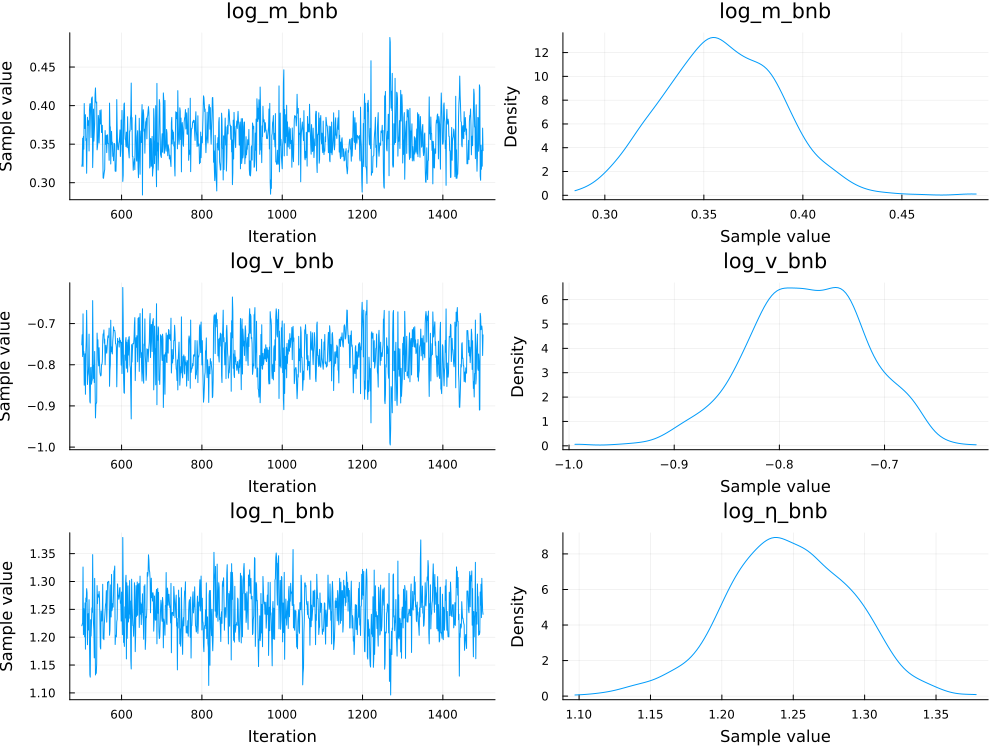

In [9]:
chn = load("../dt_intermediate/chn_bnb2_nhm_late.jld2", "result")
plot(chn)

In [22]:
include("main_utils.jl")
include("data_setup.jl")
include("comix_uk_time_series.jl")

get_mean_over_time (generic function with 1 method)

In [11]:
bnb = get_BNB2(chn)

BNB2(
m: 1.4302782211229768
v: 0.4615023970813017
η: 3.476948891012383
d: BNB(α=1.4615023970813017, β=4.296107971190916, r=0.15364530686095748)
)


In [19]:
ztbnb = zero_trunc(bnb)

ZeroTruncBNB2(
m: 1.4302782211229768
v: 0.4615023970813017
η: 3.476948891012383
d: BNB2(
m: 1.4302782211229768
v: 0.4615023970813017
η: 3.476948891012383
d: BNB(α=1.4615023970813017, β=4.296107971190916, r=0.15364530686095748)
)

)


In [24]:

pl = plot(xaxis=:log10)
plot_pdf!(pl, dds_nhm_late;
    markersize=0.5, markerstrokewidth=0.1, label=label)
plot_pdf!(pl, ztbnb)

ErrorException: type ZeroTruncBNB2 has no field p0

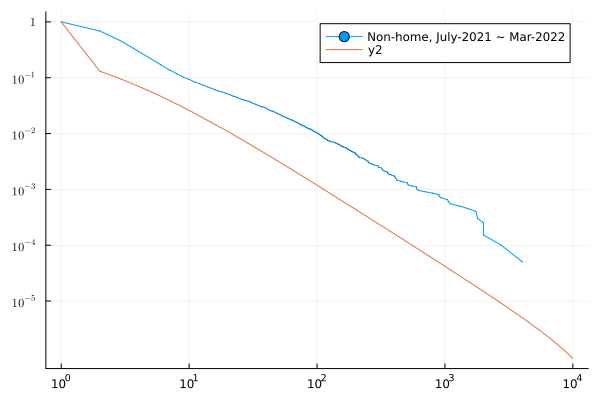

In [23]:
label = "Non-home, July-2021 ~ Mar-2022"
pl = plot(xaxis=:log10)
plot_ccdf!(pl, dds_nhm_late;
    markersize=0.5, markerstrokewidth=0.1, label=label)
plot_ccdf!(pl, ztbnb)